Our expectation with the original LEMBAS is as follows:
1) It cannot handle multiple cell types
2) It cannot account for the dispersion within a cluster at single-cell resolution, and will output the centroid of a cluster instead.

Next, we want to see whether scLEMBAS can capture the heterogeneity of cell responses upon ligand exposure. 

In [1]:
import os

import numpy as np
import pandas as pd

import anndata
import scanpy as sc
from sklearn.neighbors import NearestCentroid
from scipy.spatial.distance import cdist, pdist, squareform

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import sys

lembas = '/home/hmbaghda/Projects/LEMBAS'
sys.path.insert(1, os.path.join(lembas))
from LEMBAS.model.bionetwork import format_network, SignalingModel

sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import parse_network, io
from scLEMBAS.model.train import train_signaling_model

/tmp/ipykernel_53812/3228778271.py:4: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
n_cores = 12
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888

device = "cuda" if torch.cuda.is_available() else "cpu"

data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')
if not os.path.isdir(models_path):
    os.mkdir(models_path)

In [3]:
tf_adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'ID_tf_activity.h5ad'))

# Load and Parse Input Signaling Network

In [4]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [5]:
sn_ppis = parse_network.load_network('omnipath', organism = 'mouse', static = True)
sn_ppis = parse_network.extract_network(sn_ppis, curation_effort_thresh = 5, n_references_thresh = 3,
                                        resources = ['HuRI','IntAct','KEGG-MEDICUS','NetPath','Reactome_SignaLink3','SPIKE','SignaLink3','SIGNOR', 
                                                'Baccin2019', 'Ramilowski2015', 'Reactome_LRdb', 'UniProt_LRdb', 'CellChatDB', 'CellPhoneDB', 'connectomeDB2020', 'scConnect'], 
                                        drop_self = True, verbose = True)

The thresholds filtered 21403  of 28277 interactions
The resources filtered 937  of 6874 interactions


Filter for nodes that fall in paths between ligands and receptors (fully connected network):

In [6]:
tf_labels = tf_adata.var.index.unique().tolist()

ligand_labels = tf_adata.obs['sample'].unique().tolist()
ligand_labels = [(l[0] + l[1:].lower()).replace('-', '') for l in ligand_labels] # mouse naming convention

# filter for paths b/w ligand and tf
fn_1 = parse_network.fully_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'shortest')
fn_2 = parse_network.fully_connected_network(sn_ppis, ligand_labels, tf_labels, source_label = source_label, target_label = target_label, 
                       path_finder = 'connected')
# of the methods to identify paths, retain the one that has the most interactions
if fn_1.shape[0] > fn_2.shape[0]:
    sn_ppis = fn_1
else:
    sn_ppis = fn_2

del fn_1, fn_2

100%|████████████████████████████████████| 8122/8122 [00:00<00:00, 21211.94it/s]


Finally, let's format the network as needed for input to building the model:

In [7]:
# for the interactions that are labeled as both stimulating and inhibiting, relabel them as unknown (can only have one direction)
sn_ppis.loc[sn_ppis[(sn_ppis[stimulation_label] == 1) & (sn_ppis[inhibition_label] == 1)].index, 
    [stimulation_label, inhibition_label]] = [False, False]
sn_ppis = format_network(sn_ppis, weight_label, stimulation_label, inhibition_label) 

sn_ppis[[source_label, target_label, stimulation_label, inhibition_label, weight_label]].head()

,source_genesymbol,target_genesymbol,consensus_stimulation,consensus_inhibition,mode_of_action
0,Mapk14,Mapkapk2,True,False,1.0
1,Mapkapk2,Mapk14,False,False,0.1
2,Akt1,Chuk,True,False,1.0
3,Tp53,Atf3,True,False,1.0
4,Abl1,Tp73,True,False,1.0


In [8]:
print('The signaling network contains {} interactions'.format(sn_ppis.shape[0]))
sn_ppis[[source_label, target_label, weight_label, stimulation_label, inhibition_label]].head()

The signaling network contains 619 interactions


,source_genesymbol,target_genesymbol,mode_of_action,consensus_stimulation,consensus_inhibition
0,Mapk14,Mapkapk2,1.0,True,False
1,Mapkapk2,Mapk14,0.1,False,False
2,Akt1,Chuk,1.0,True,False
3,Tp53,Atf3,1.0,True,False
4,Abl1,Tp73,1.0,True,False


The interactions include the following input ligands:

In [9]:
all_nodes = sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()
input_ligands_available = sorted(set(ligand_labels).intersection(all_nodes))
print(*input_ligands_available, sep = ', ')

Egf, Gdnf, Hgf, Ifng, Il10, Il11, Il13, Il15, Il1a, Il1b, Il2, Il21, Il4, Il5, Il6, Il7, Il9, Lif, Osm, Tslp


# Explore performance on TF activity

## Scenario 1:

In [10]:
model_no = 1

The simplest scenario is:
- 1 cell type
- 1 ligand
- Binary ligand exposure (0 or 1)
- Exposure leads to distinct clusters in TF activity space

To identify the two most distinct clusters, let's calculate the Euclidean distance of the cluster centroids in PC space:

In [11]:
group_label = 'TF_clusters' # ordered cateogry in obs

pca_rank = tf_adata.uns['pca']['pca_rank']
X_pca = tf_adata.obsm['X_pca'][:, :pca_rank] # PCA to pca_rank components

clf = NearestCentroid()
clf.fit(X_pca, np.array(tf_adata.obs[group_label]))
centroids = clf.centroids_ # group labels x n_pcs
ped = squareform(pdist(centroids, 'euclidean')) # euclidean distance between all centroids

max_clusters = np.unravel_index(np.argmax(ped), ped.shape)
max_clusters = [clf.classes_[i] for i in max_clusters]
print('Centroid euclidean distance in PC space is maximized between cluster {} and {} ({} PCs)'.format(*max_clusters, tf_adata.uns['pca']['pca_rank']))

ped_ = ped.copy()
np.fill_diagonal(ped_, np.inf)
min_clusters = np.unravel_index(np.argmin(ped_), ped_.shape)
min_clusters = [clf.classes_[i] for i in min_clusters]
print('Centroid euclidean distance in PC space is minimized between cluster {} and {} ({} PCs)'.format(*min_clusters, tf_adata.uns['pca']['pca_rank']))

Centroid euclidean distance in PC space is maximized between cluster 11 and 15 (8 PCs)
Centroid euclidean distance in PC space is minimized between cluster 11 and 9 (8 PCs)


Let's also get the within-cluster dispersion, as measured by WCSS. We adapt the below equation of WCSS to calculate just the inner sum for each cluster(not summing across all clusters, which gives one metric of overall dispersion) and normalize to the total number of points in the cluster:



$$
\text{WCSS} = \sum_{i=1}^{k} \sum_{\mathbf{x} \in C_i} [d(\mathbf{x}, \mathbf{\mu}_i)]^2
$$


- $k$: The number of clusters.
- $C_i$: The set of points belonging to the $i$-th cluster.
- $\mathbf{x}$: A data point within a cluster $C_i$.
- $\mathbf{\mu}_i$: The centroid of the $i$-th cluster, which is the average position of all the points in $C_i$.
- $d(\mathbf{x}, \mathbf{\mu}_i)$: The distance between a data point $\mathbf{x}$ and the centroid (here calculated as Euclidean distance)

Our WCSS:

For each $k$k:
$$
\text{WCSS} = \sum_{\mathbf{x} \in C_i} [d(\mathbf{x}, \mathbf{\mu}_i)]^2 / n
$$

- $n$: The total number of points in the cluster


In [12]:
WCSS = {}
cluster_map = tf_adata.obs[['TF_clusters']].reset_index(drop = True)
for i, centroid in enumerate(centroids):
    cluster_label = clf.classes_[i]
    cluster_indeces = cluster_map[cluster_map.TF_clusters == cluster_label].index.tolist()
    cluster_points = X_pca[cluster_indeces,:]

    # squared_distances = np.sum((cluster_points - centroid) ** 2, axis=1)
    euclidean_distance = cdist(cluster_points, [centroid], 'euclidean')
    squared_distances = np.sum(euclidean_distance**2, axis = 1)

    WCSS[cluster_label] = np.sum(euclidean_distance**2)/cluster_points.shape[0]

WCSS = pd.DataFrame(WCSS.items(), columns = ['TF_cluster', 'WCSS'])
WCSS.sort_values(by = 'WCSS', ascending = True, inplace = True)
WCSS.reset_index(drop = True, inplace = True)

max_cluster, min_cluster = WCSS.loc[WCSS.WCSS.idxmax(), 'TF_cluster'], WCSS.loc[WCSS.WCSS.idxmin(),  'TF_cluster']
print('Cluster {} has the max dispersion in PC space'.format(max_cluster))
print('Cluster {} has the min dispersion in PC space'.format(min_cluster))

Cluster 8 has the max dispersion in PC space
Cluster 11 has the min dispersion in PC space


/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired v

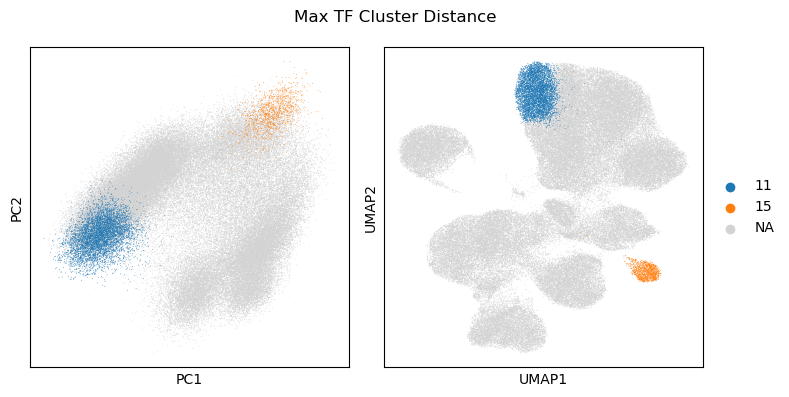

In [13]:
viz_adata = tf_adata.copy()
viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
                                                       categories = max_clusters, 
                                                       ordered = True)
fig, ax = plt.subplots(ncols = 2, figsize = (8, 4))
sc.pl.pca(viz_adata, color=group_label + '_color', ax = ax[0], show = False)
ax[0].legend().set_visible(False)
ax[0].set_title('')
sc.pl.umap(viz_adata, color=group_label + '_color', ax = ax[1], show = False)
ax[1].set_title('')

fig.suptitle('Max TF Cluster Distance')

fig.tight_layout()
# plt.savefig(fname = os.path.join(data_path, 'figures', 'tf_celltype_umap.png'), 
#             transparent = True, 
#             bbox_inches = 'tight')
plt.show()

Based on these results, let's say that cluster 11 is unstimulated, and cluster 15 is stimulated. 

In [87]:
np.random.seed(seed)
selected_ligand = np.random.choice(input_ligands_available, 1)[0]
print('The selected ligand is: ' + selected_ligand)

subset_tf = tf_adata[tf_adata.obs.TF_clusters.isin(['11', '15'])]
subset_tf.obs.TF_clusters.value_counts()

The selected ligand is: Il5


TF_clusters
11    5520
15    1168
Name: count, dtype: int64

To avoid any bias, let's randomly subset the larger cluster to match the size of the smaller one:

In [88]:
# sample_size = subset_tf.obs.TF_clusters.value_counts().min()
# large_cluster = subset_tf.obs.TF_clusters.value_counts().idxmax()
# small_cluster = subset_tf.obs.TF_clusters.value_counts().idxmin()
# large_cluster_barcodes = subset_tf.obs[subset_tf.obs.TF_clusters == large_cluster].index
# small_cluster_barcodes = subset_tf.obs[subset_tf.obs.TF_clusters == small_cluster].index.tolist()
# np.random.seed(seed)
# lcb_sub = list(np.random.choice(large_cluster_barcodes, sample_size, replace = False))
# subset_tf = subset_tf[lcb_sub + small_cluster_barcodes, :]
# subset_tf.obs.TF_clusters.value_counts()

For now, for speed, let's subset so that there are just 100 "samples" per stimulation condition:

In [89]:
sample_size = 100

barcodes = []
for cluster_label in subset_tf.obs.TF_clusters.unique():
    bc = subset_tf.obs[subset_tf.obs.TF_clusters == cluster_label].index
    np.random.seed(seed)
    barcodes += list(np.random.choice(bc, sample_size, replace = False))
subset_tf = subset_tf[barcodes, :]
subset_tf.obs.TF_clusters.value_counts()

TF_clusters
11    100
15    100
Name: count, dtype: int64

Next, let's initialize the model:

In [92]:
ligand_input = pd.DataFrame(subset_tf.obs.TF_clusters.map({'11': 0, '15': 1}))
ligand_input.columns = [selected_ligand]
tf_output = pd.DataFrame(subset_tf.X, index = subset_tf.obs.index, columns = subset_tf.var.index)

In [93]:
# linear scaling of inputs/outputs
projection_amplitude_in = 3
projection_amplitude_out = 1.2
# other parameters
bionet_params = {'target_steps': 100, 'max_steps': 120, 'exp_factor':50, 'tolerance': 1e-5, 'leak':1e-2} # fed directly to model

# training parameters
lr_params = {'max_iter': 5000, 
             'learning_rate': 2e-3}
other_params = {'batch_size': 64, 'noise_level': 10, 'gradient_noise_level': 1e-9}
regularization_params = {'param_lambda_L2': 1e-6, 'moa_lambda_L1': 0.1, 'ligand_lambda_L2': 1e-5, 'uniform_lambda_L2': 1e-4, 
                   'uniform_max': 1/projection_amplitude_out, 'spectral_loss_factor': 1e-5}
spectral_radius_params = {'n_probes_spectral': 5, 'power_steps_spectral': 50, 'subset_n_spectral': 10}
target_spectral_radius = 0.8
hyper_params = {**lr_params, **other_params, **regularization_params, **spectral_radius_params} # fed into training function

In [94]:
mod = SignalingModel(net = sn_ppis,
                     X_in = ligand_input,
                     y_out = tf_output, 
                     projection_amplitude_in = projection_amplitude_in, projection_amplitude_out = projection_amplitude_out,
                     weight_label = weight_label, source_label = source_label, target_label = target_label,
                     bionet_params = bionet_params, 
                     dtype = torch.float32, device = device, seed = seed)

Next, let's train the model:

In [95]:
# model setup
mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius

# loss and optimizer
loss_fn = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam

# training loop
res = train_signaling_model(mod, optimizer, loss_fn,
                            reset_epoch = 200,
                            hyper_params = hyper_params,
                            train_split_frac = {'train': 0.8, 'test': 0.2, 'validation': None},
                            train_seed = seed,
                            verbose = True)
mod, cur_loss, cur_eig, mean_loss, stats, X_train, X_test, X_val, y_train, y_test, y_val = res

# store results
io.write_pickled_object(stats, os.path.join(models_path, 'model_' + str(model_no) + '_training_stats.pickle'))
torch.save(obj=mod.state_dict(), f=os.path.join(models_path, 'model_' + str(model_no) + '_state_dict.pth'))

  0%|                                          | 1/5000 [00:00<21:57,  3.80it/s]

i=0, l=1.25381, s=0.861, r=0.00020, v=0


  1%|▍                                        | 51/5000 [00:15<24:07,  3.42it/s]

i=50, l=1.13707, s=0.840, r=0.00021, v=0


  2%|▊                                       | 101/5000 [00:27<16:50,  4.85it/s]

...

i=4900, l=0.39329, s=0.453, r=0.00000, v=0


 99%|██████████████████████████████████████▌| 4951/5000 [16:05<00:11,  4.38it/s]

i=4950, l=0.39278, s=0.444, r=0.00000, v=0


100%|███████████████████████████████████████| 5000/5000 [16:16<00:00,  5.12it/s]

Training ran in: 16 min 16.07 sec


Let's see what the output looks like:

In [96]:
y_pred, Y_full = mod(mod.df_to_tensor(X_test))
y_pred = y_pred.cpu().detach().numpy()

print('The number of unique predictions across all test data is {}'.format(len(np.unique(y_pred, axis = 0))))

The number of unique predictions across all test data is 2


We can see that there are only 2 unique prediction values, because the model is currently not aware of single-cell resolution (or cell type) data. Let's see what exactly these predicted values are:

In [176]:
ligand_input[selected_ligand] = pd.Categorical(ligand_input[selected_ligand], 
                                              categories = sorted(ligand_input[selected_ligand].unique()), 
                                              ordered = True)

clf = NearestCentroid()
clf.fit(y_train, ligand_input.loc[y_train.index, selected_ligand])
train_centroids = pd.DataFrame(clf.centroids_ , index = clf.classes_, columns = y_train.columns)

y_pred_1, _ = mod(mod.df_to_tensor(pd.DataFrame(X_test[X_test[selected_ligand] == 1].iloc[0, :]).T))
y_pred_1 = y_pred_1.cpu().detach().numpy()
y_pred_0, _ = mod(mod.df_to_tensor(pd.DataFrame(X_test[X_test[selected_ligand] == 0].iloc[0, :]).T))
y_pred_0 = y_pred_0.cpu().detach().numpy()

In [137]:
y_train_eds = list()
for idx in y_train.index:
    y_vals = y_train.loc[idx, :]
    pred_type = ligand_input.loc[idx, selected_ligand]
    y_centroid = train_centroids.loc[pred_type, :]

    ed = np.linalg.norm(y_vals - y_centroid)
    y_train_eds.append(ed)

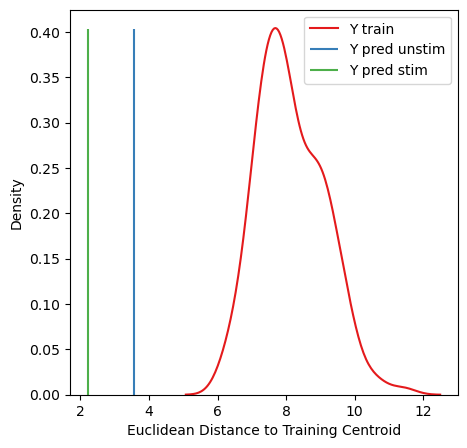

In [159]:
fig, ax = plt.subplots(figsize = (5,5))

colors = sns.color_palette('Set1')

sns.kdeplot(y_train_eds, ax = ax, color = colors[0])
children = plt.gca().get_children()
l0 = ax.vlines(np.linalg.norm(y_pred_0 - centroids.loc[0,:].values), ymin = 0, ymax = 0.95*ax.get_ylim()[1], color = colors[1])
l1 = ax.vlines(np.linalg.norm(y_pred_1 - centroids.loc[1,:].values), ymin = 0, ymax = 0.95*ax.get_ylim()[1], color = colors[2])

ax.set_xlabel('Euclidean Distance to Training Centroid')

plt.legend([children[0], l0, l1], ['Y train', 'Y pred unstim', 'Y pred stim'] )

Above, we see that the Euclidean distance of the predicted values to the training centroids is much smaller than the distances of any of the actual training values to the training centroids. This quantitatively shows us that the model is currently predicting the average of the training data for a given stimulation condition.

# To do

Show the centroid and predicted values in the PCA space:

In [212]:
# group_label = 'Type'

# viz_adata = subset_tf.copy()
# viz_adata.obs[group_label] = 'train'
# viz_adata.obs.loc[y_test.index, group_label] = 'test'

# # viz_adata.obs[group_label + '_color'] = pd.Categorical(viz_adata.obs[group_label], 
# #                                                        categories = max_clusters, 
# #                                                        ordered = True)
# fig, ax = plt.subplots(ncols = 1, figsize = (4, 4))
# sc.pl.pca(viz_adata, color=group_label, size = 10, ax = ax, show = False)
# ax.set_title('')
# # adata_centroids = anndata.AnnData(train_centroids, obs = pd.DataFrame(train_centroids.index, columns = ['stimulation']))
# # subset_tf.obs['stimulation'] = ligand_input.loc[subset_tf.obs.index, selected_ligand]
# # test = sc.tl.ingest(adata_centroid, subset_tf[y_train.index, :], embedding_method = 'pca', obs = 'stimulation')